# Geokodning av kundinlåningskonton för CRA-marknadsområdeskartläggning

## Sammanfattning

En retailbank omvandlar kunders postnummer (och filialidentifierare) till longitud-/latitudkoordinater med **PROC GEOCODE**, så att dess compliance- och nätverksplaneringsteam kan kartlägga var inlåningen koncentreras. Notebooken geokodar konton efter postnummer med en automatisk stad/delstat-reserv, kopplar kommun- och inkomstnivåattribut för granskning av CRA-bedömningsområden (Community Reinvestment Act), jämför strikt postnummermatchning via `NOCITY`, och använder `METHOD=CUSTOM` för att placera filialnätet efter filialkod.

## Datakällor

All data genereras inline med ett DATA-steg (`call streaminit`/`rand`); inga externa filer eller nätverksåtkomst används.

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `ziplookup` | 8 | `zip`, `city`, `state`, `x`, `y`, `county`, `income_tier` | Referenstabell som kopplar femsiffriga postnummer till centroidlongitud (`x`) / latitud (`y`) plus CRA-attribut (kommun, inkomstnivå). |
| `accounts` | 100 | `account_id`, `zip`, `city`, `state`, `deposit_bal` | Syntetiska inlåningskonton i detaljhandeln; varje konto drar ett föråldrat postnummer (`00000`) med ~12 % sannolikhet men behåller en giltig stad/delstat så att stadsreserven kan återställa det. I denna körning blev 7 av de 100 kontona föråldrade. |
| `branchref` | 4 | `branch_code`, `x`, `y`, `region` | Anpassad uppslagning av fysiska filialkoordinater nyckelad på filialkod. |
| `branches` | 4 | `branch_code`, `atm_count` | Filialnätverkets register som ska geokodas med `METHOD=CUSTOM`. |

# Geokodning av kundinlåningskonton för CRA-marknadsområdeskartläggning

Tillsynsmyndigheter förväntar sig att retailbanker visar var de tar emot inlåning och beviljar krediter i förhållande till sitt filialavtryck — kärnan i **Community Reinvestment Act (CRA)**-bedömningsområdesanalys. Innan någon karta eller inkomstnivåsammanställning kan tas fram måste råa kontoposter (som bara har ett postnummer och stad/delstat) omvandlas till geografiska koordinater.

`PROC GEOCODE` utför precis den översättningen: den matchar adressfält i ett indataset mot ett koordinat-**uppslagnings**dataset och lägger till longitud (`X`), latitud (`Y`) och en `_MATCHED_`-indikator. I denna notebook:

1. Bygger vi en postnummer-centroidreferenstabell berikad med kommun- och inkomstnivåattribut.
2. Geokodar vi 100 syntetiska inlåningskonton efter postnummer, med en automatisk stad/delstat-reserv.
3. Jämför vi strikt postnummermatchning med alternativet `NOCITY`.
4. Geokodar vi det fysiska filialnätet med `METHOD=CUSTOM` nyckelat på filialkod.
5. Sammanfattar vi matchningsgrad, geografisk spridning och inlåning per inkomstnivå.

## Steg 1 — Bygg postnummer-centroidreferensen (uppslagning)

Produktionsjobb pekar `LOOKUP=` mot `SASHELP.ZIPCODE`, men här genererar vi en liten, självständig referens inline. Varje rad kopplar ett femsiffrigt postnummer till dess centroidlongitud (`x`) och latitud (`y`). Vi bär också med två **icke-geokodande** attribut — `county` och `income_tier` — som `ATTRIBUTEVAR=` kopierar till varje matchat konto för CRA-bedömningsområdesarbete.

In [1]:
data ziplookup;
  LÄNGD city $24 state $2 county $24 income_tier $10;
  INDATA zip $5. city $ state $ x y county $ income_tier $;
  DATALINES;
10001 NewYork NY -73.9967 40.7484 Manhattan Hög
60601 Chicago IL -87.6186 41.8819 Cook Medel
90210 BeverlyHills CA -118.4065 34.0901 LosAngeles Hög
33101 Miami FL -80.1918 25.7617 MiamiDade Medel
98101 Seattle WA -122.3321 47.6062 King Hög
77002 Houston TX -95.3698 29.7604 Harris Medel
30303 Atlanta GA -84.3880 33.7490 Fulton Medel
85004 Phoenix AZ -112.0740 33.4484 Maricopa Låg
;
KÖR;


NOTE: DATA ziplookup

NOTE: Processing inline DATALINES (8 lines)

NOTE: Read 8 rows from DATALINES.
NOTE: Wrote ziplookup (8 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Steg 2 — Generera syntetiska inlåningskonton

Vi simulerar 100 inlåningskonton i detaljhandeln. Varje konto tilldelas slumpmässigt ett av de åtta marknadspostnumren. Insättningssaldon följer en lognormalfördelning (en realistisk form för kontosaldon — många små saldon, en lång högersvans). För att öva geokodarens reservlogik drar varje konto oberoende ett föråldrat platshållarpostnummer (`00000`) med ~12 % sannolikhet; ett föråldrat postnummer misslyckas med den primära postnummermatchningen men behåller ändå en giltig `city`/`state`. Med detta frö blir 7 av de 100 kontona föråldrade.

In [2]:
data accounts;
  CALL streaminit(20250529);
  LÄNGD city $24 state $2;
  FÄLT zips[8] $5 _temporary_
    ('10001' '60601' '90210' '33101' '98101' '77002' '30303' '85004');
  FÄLT cty[8] $24 _temporary_
    ('NewYork' 'Chicago' 'BeverlyHills' 'Miami' 'Seattle' 'Houston' 'Atlanta' 'Phoenix');
  FÄLT stt[8] $2 _temporary_
    ('NY' 'IL' 'CA' 'FL' 'WA' 'TX' 'GA' 'AZ');
  GÖR account_id = 1 TILL 100;
    k = 1 + floor(rand('uniform') * 8);
    city  = cty[k];
    state = stt[k];
    /* ett foraldrat postnummer (~12% dragningsfrekvens) som endast stad/delstat-fallbacken kan losa upp */
    OM rand('uniform') < 0.12 SÅ zip = '00000';
    ANNARS zip = zips[k];
    deposit_bal = round(rand('lognormal') * 5000 + 500, 0.01);
    UTDATA;
  SLUT;
  TA_BORT k;
KÖR;


NOTE: DATA accounts


NOTE: Wrote accounts (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Steg 3 — Geokoda konton efter postnummer med en stad/delstat-reserv

Standardmetoden `METHOD=ZIP` matchar varje kontos postnummer mot uppslagningens centroid. När ett postnummer inte matchar faller `PROC GEOCODE` automatiskt tillbaka på en `city`+`state`-matchning (om inte `NOCITY` är satt). Alternativet `ATTRIBUTEVAR=(county income_tier)` för in de två referensattributen i utdata, och `_MATCHED_` registrerar hur varje rad löstes (`ZIP`, `CITY` eller `No match`).

In [3]:
PROCEDUR GEOCODE data=accounts out=geo_accounts
    METHOD=zip lookup=ziplookup
    attributevar=(county income_tier);
    ETIKETT county='Kommun' income_tier='Inkomstnivå';
KÖR;

PROCEDUR SKRIV data=geo_accounts(obs=8) noobs;
  VARIABEL account_id zip city state x y _matched_ county income_tier;
  ETIKETT account_id='Konto-ID' zip='Postnummer' city='Stad' state='Delstat'
        x='Longitud' y='Latitud' _matched_='Matchning'
        county='Kommun' income_tier='Inkomstnivå';
KÖR;


Konto-ID  Postnummer     Stad  Delstat   Longitud  Latitud  Matchning     Kommun   Inkomstnivå
--------  ----------  -------  -------  ---------  -------  ---------  ---------  ------------
       1       33101  Miami    FL        -80.1918  25.7617  ZIP        MiamiDade  Medel
       2       98101  Seattle  WA       -122.3321  47.6062  ZIP        King       Hög
       3       77002  Houston  TX        -95.3698  29.7604  ZIP        Harris     Medel
       4       85004  Phoenix  AZ        -112.074  33.4484  ZIP        Maricopa   Låg
       5       85004  Phoenix  AZ        -112.074  33.4484  ZIP        Maricopa   Låg
       6       60601  Chicago  IL        -87.6186  41.8819  ZIP        Cook       Medel
       7       98101  Seattle  WA       -122.3321  47.6062  ZIP        King       Hög
       8       60601  Chicago  IL        -87.6186  41.8819  ZIP        Cook       Medel

... 92 more observations (showing 8 of 100)




NOTE: PROC GEOCODE data=accounts

NOTE: PROC GEOCODE: 100 observations geocoded, output to ./work/547c257d-fd7c-40e9-8bb2-77d4982b2a14/geo_accounts.avro
NOTE: PROC PRINT data=geo_accounts

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Steg 4 — Granska matchningskvalitet och det geografiska avtrycket

Frekvenstabellen för `_MATCHED_` visar för compliance-teamet hur många konton som löstes via postnummer jämfört med de som räddades av stad/delstat-reserven — kontona med föråldrat postnummer bör visas som `CITY`-matchningar. `PROC MEANS` bekräftar att longitud- (`x`) och latitudintervallen (`y`) täcker det förväntade kontinentala USA-avtrycket, och sammanfattar inlåningssaldon.

                                                   The FREQ Procedure

Matchning    Frequency    Percent
----------------------------------
CITY                 7      7.00
ZIP                 93     93.00
                                                  The MEANS Procedure

 Variable     Label                     N           Mean     Minimum     Maximum
 -------------------------------------------------------------------------------
 DEPOSIT_BAL  Insättningssaldo        100        7845.32     1066.62    26800.73
 X            Longitud                100         -93.86     -122.33      -74.00
 Y            Latitud                 100          35.96       25.76       47.61
 -------------------------------------------------------------------------------

                                                  The MEANS Procedure

                                    Analysis Variable : DEPOSIT_BAL Insättningssaldo

                                                      N
                       


NOTE: PROC FREQ
NOTE: ODS plot written: freq__matched_.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


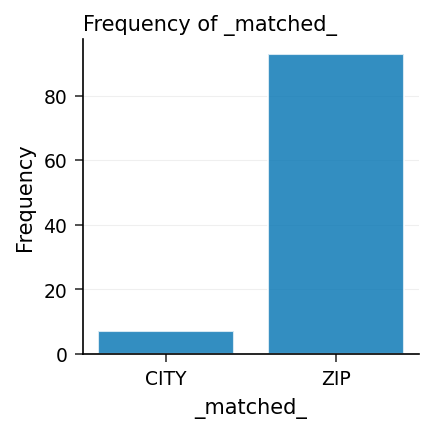

In [4]:
PROCEDUR FREKVENSER data=geo_accounts;
  TABLES _matched_ / nocum;
  ETIKETT _matched_='Matchning';
KÖR;

PROCEDUR MEDELVÄRDEN data=geo_accounts n mean MIN MAX maxdec=2;
  VARIABEL deposit_bal x y;
  ETIKETT deposit_bal='Insättningssaldo' x='Longitud' y='Latitud';
KÖR;

PROCEDUR MEDELVÄRDEN data=geo_accounts sum mean maxdec=2;
  KLASS income_tier;
  VARIABEL deposit_bal;
  ETIKETT income_tier='Inkomstnivå' deposit_bal='Insättningssaldo';
KÖR;

## Steg 5 — Jämför strikt postnummermatchning med NOCITY

För vissa regulatoriska sammanställningar är endast en verifierad postnummermatchning acceptabel — en stad/delstat-reserv skulle kunna placera ett konto i fel folkräkningsområde. Att köra om med flaggan `NOCITY` inaktiverar reserven, så kontona med föråldrat postnummer visas nu som `No match` (med saknade koordinater) istället för att tyst omplaceras. Att jämföra de två `_MATCHED_`-fördelningarna kvantifierar hur mycket täckning reserven ger.

                                                   The FREQ Procedure

Matchning    Frequency    Percent
----------------------------------
No match             7      7.00
ZIP                 93     93.00



NOTE: PROC GEOCODE data=accounts

NOTE: PROC GEOCODE: 100 observations geocoded, output to ./work/547c257d-fd7c-40e9-8bb2-77d4982b2a14/geo_strict.avro
NOTE: PROC FREQ
NOTE: ODS plot written: freq__matched_.spec.json
NOTE: PROC FREQ statement used.


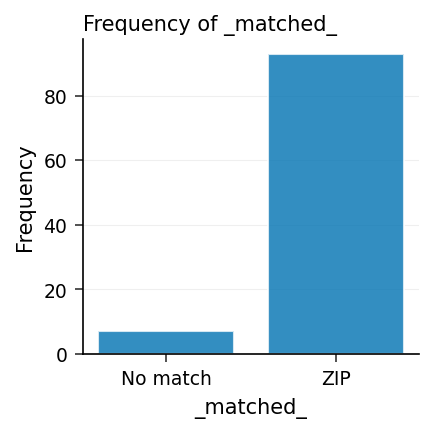

In [5]:
PROCEDUR GEOCODE data=accounts out=geo_strict
    METHOD=zip lookup=ziplookup nocity
    attributevar=(county income_tier);
KÖR;

PROCEDUR FREKVENSER data=geo_strict;
  TABLES _matched_ / nocum;
  ETIKETT _matched_='Matchning';
KÖR;

## Steg 6 — Geokoda filialnätet med METHOD=CUSTOM

Filial- och bankomatplatser adresseras inte via postnummercentroider — banken känner redan till varje plats exakta koordinater, nyckelade på en intern `branch_code`. `METHOD=CUSTOM` med `LOOKUPVAR=branch_code` kopplar registret till en koordinatreferens på den nyckeln, vilket låter oss rita det fysiska nätet tillsammans med den geokodade inlåningsbasen. `ATTRIBUTEVAR=(region)` för med sig tillsynsregionen.

In [6]:
data branchref;
  LÄNGD branch_code $4 region $16;
  INDATA branch_code $ x y region $;
  DATALINES;
B001 -73.9967 40.7484 Nordöst
B002 -87.6186 41.8819 Mellanvästern
B003 -118.4065 34.0901 Väst
B004 -80.1918 25.7617 Sydöst
;
KÖR;

data branches;
  LÄNGD branch_code $4;
  INDATA branch_code $ atm_count;
  DATALINES;
B001 12
B002 8
B003 5
B004 7
;
KÖR;

PROCEDUR GEOCODE data=branches out=geo_branch
    METHOD=custom lookup=branchref
    lookupvar=branch_code
    attributevar=(region);
    ETIKETT region='Region';
KÖR;

PROCEDUR SKRIV data=geo_branch noobs;
  VARIABEL branch_code atm_count region x y _matched_;
  ETIKETT branch_code='Filialkod' atm_count='Bankomater' region='Region'
        x='Longitud' y='Latitud' _matched_='Matchning';
KÖR;


Filialkod  Bankomater          Region   Longitud  Latitud  Matchning
---------  ----------  --------------  ---------  -------  ---------
B001               12  Nordöst          -73.9967  40.7484  CUSTOM
B002                8  Mellanvästern    -87.6186  41.8819  CUSTOM
B003                5  Väst            -118.4065  34.0901  CUSTOM
B004                7  Sydöst           -80.1918  25.7617  CUSTOM




NOTE: DATA branchref

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote branchref (4 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA branches

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote branches (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC GEOCODE data=branches

NOTE: PROC GEOCODE: 4 observations geocoded, output to ./work/547c257d-fd7c-40e9-8bb2-77d4982b2a14/geo_branch.avro
NOTE: PROC PRINT data=geo_branch

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


## Tolkning av resultaten

- **Täckning.** Standardkörningen med postnummer löser 93 av de 100 kontona som `ZIP`-matchningar, och de 7 kontona med föråldrat postnummer återställs som `CITY`-matchningar via den automatiska reserven — så varje konto får koordinater. `NOCITY`-körningen sänker samma 7 konton till `No match` (`_MATCHED_`-fördelningen ändras från 93 ZIP / 7 CITY till 93 ZIP / 7 No match), vilket tydliggör avvägningen mellan täckning (reserv på) och positionsprecision (reserv av).
- **CRA-attribut följer med geokodningen.** Eftersom `ATTRIBUTEVAR=` kopierade `county` och `income_tier` till varje matchad rad är sammanställningen `PROC MEANS ... CLASS income_tier` av inlåningssaldon klar för bedömningsområdesrapportering utan en separat koppling. I denna körning fördelas inlåningen på 46 konton i kommuner med inkomstnivå Medel (summa \$370,592, medelvärde \$8,056), 42 i kommuner med inkomstnivå Hög (summa \$324,804, medelvärde \$7,733) och 12 i kommuner med inkomstnivå Låg (summa \$89,136, medelvärde \$7,428) — så banken direkt kan se hur inlåningen fördelas över inkomstnivåerna.
- **Kontroll av det geografiska avtrycket.** Intervallen för `X` (longitud −122.33 till −74.00, medelvärde −93.86) och `Y` (latitud 25.76 till 47.61, medelvärde 35.96) bekräftar att de geokodade punkterna faller inom det förväntade kontinentala USA-spannet, en snabb kontroll mot omkastade eller feltecknade koordinater. De 100 kontona har ett genomsnittligt inlåningssaldo på \$7,845 (min \$1,067, max \$26,801), i linje med den långsvansade lognormalgeneratorn.
- **Filialnätet placerat oberoende.** `METHOD=CUSTOM` löser alla 4 filialer via deras interna kod (varje rad rapporterar `_MATCHED_=CUSTOM`), så det fysiska nätet och kundinlåningsbasen delar nu ett gemensamt koordinatsystem — grunden för nedströms gap-analys av filialtäckning och CRA-bedömningsområdeskartor.

Med kunder och filialer geokodade är de naturliga nästa stegen rumsliga överlagringar (punkt-i-polygon mot folkräkningsområden), värmekartor över inlåningskoncentration, och avstånd-till-närmaste-filial-mått som matar både compliance-rapportering och beslut om nätverksexpansion.